# Hotel Booking Cancellation Prediction
## Comparing Decision Tree, Ensemble and XG Boosting MOdels for Cancellation Risk and Revenue

We analyzed the cancellation risk associated every booking at the time of booking and forcast the cancellation risk associated with the booking, and estimated the expected revenue to be loss if the booking is realized as a means for hotels to priority high risk and high revenue bookings.

We use tree based models and ensemble models famously knowned for capturing complex relationship like the hotel entity and patterns that a logisitc regression can't. A goal is increase the correctness of the model in detecting a booking will be canceled. 

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sckit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# models(decision trees, random forest, gradient boosting)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [68]:
# load data
hotel_bookings = pd.read_csv('/Users/kiepeeh1/Documents/00 Working Projects/Hotel Data Analytics/Hotel Analytics/Data/Processed_Data/final_hotel_bookings.csv')

In [74]:
hotel_bookings['is_canceled'] = hotel_bookings['is_canceled'].astype('category') 
   
# convert all Dtype == 'object' columns to categorical type
for col in hotel_bookings.select_dtypes(include='object').columns:
    hotel_bookings[col] = hotel_bookings[col].astype('category')

In [75]:
# split the data into features and target variable
feature_cols = [
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number', 'adults'
]
# ensure this only apply to categorical columns
X = pd.get_dummies(hotel_bookings[feature_cols], drop_first=False)

#X = hotel_bookings[feature_cols]
y = hotel_bookings['is_canceled']

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=19)
print(f"Training set size: {round(len(X_train)/len(X)*100)}% \n\
Testing set size: {round(len(X_test)/len(X)*100)}%")

Training set size: 70% 
Testing set size: 30%


In [77]:
# Build models
decision_tree = DecisionTreeClassifier(random_state=19)

# fit the model
decision_tree.fit(X_train, y_train)

# predictions
y_pred_dt = decision_tree.predict(X_test)

# classification report
print("Decision Tree Classifier:")
target_names = ['Not Canceled', 'Canceled']
print(classification_report(y_test, y_pred_dt, target_names=target_names))

Decision Tree Classifier:
              precision    recall  f1-score   support

Not Canceled       0.79      0.79      0.79     19011
    Canceled       0.45      0.46      0.46      7208

    accuracy                           0.70     26219
   macro avg       0.62      0.62      0.62     26219
weighted avg       0.70      0.70      0.70     26219



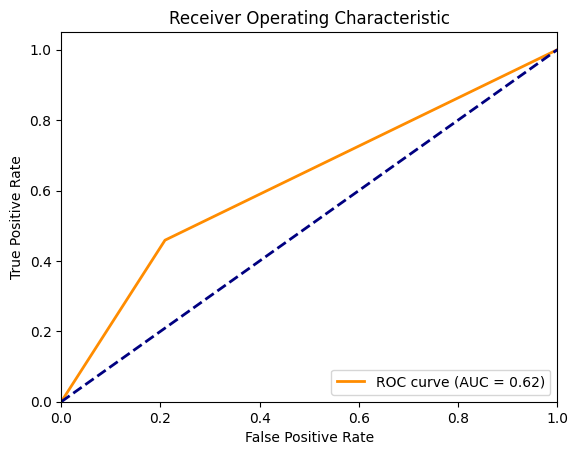

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_pred_dt)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [18]:
# confusion matrix
cnf_matrix = confusion_matrix(y_test, y_pred_dt)
cnf_matrix_df = pd.DataFrame(cnf_matrix, index = ['Not Canceled', 'Canceled'], 
columns = ['Predicted Not Canceled', 'Predicted Canceled'])
cnf_matrix_df

,Predicted Not Canceled,Predicted Canceled
Not Canceled,15035,3976
Canceled,3900,3308


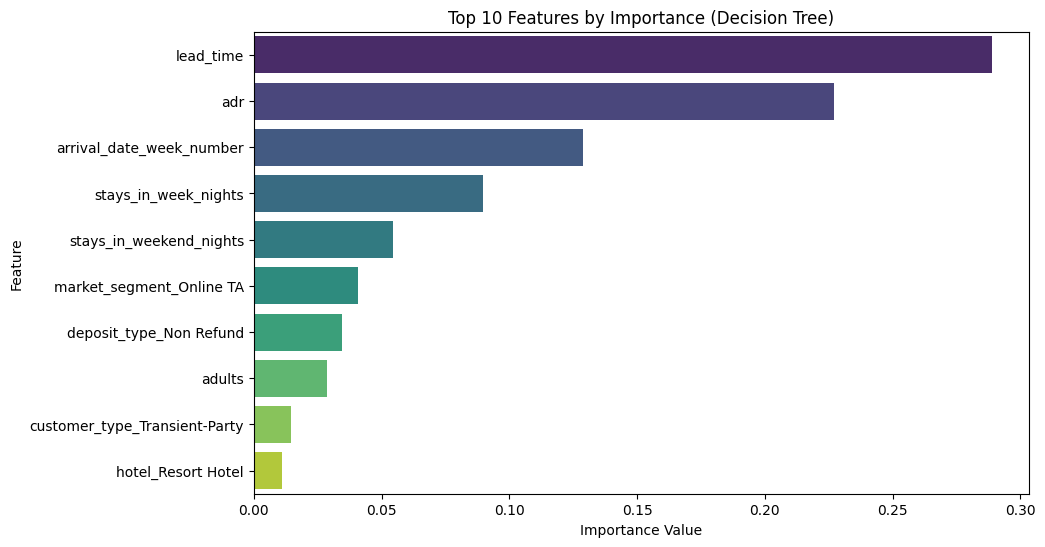

In [35]:
# plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_dt.head(10), hue='feature', palette='viridis')
plt.title('Top 10 Features by Importance (Decision Tree)')
plt.xlabel('Importance Value')
plt.ylabel('Feature')
plt.show()

In [28]:
# decision tree feature importance
feature_importance_dt = pd.DataFrame({
    'feature': X_test.columns,
    'importance': decision_tree.feature_importances_
}).sort_values(by='importance', ascending=False) 

print("Top 10 Features by Importance (Decision Tree)")
display(feature_importance_dt.head(10))

print("Least 10 Features by Importance (Decision Tree)")
display(feature_importance_dt.nsmallest(10, 'importance').copy())

Top 10 Features by Importance (Decision Tree)


,feature,importance
0,lead_time,0.288801
3,adr,0.226962
4,arrival_date_week_number,0.128766
1,stays_in_week_nights,0.089820
2,stays_in_weekend_nights,0.054314
12,market_segment_Online TA,0.040953
26,deposit_type_Non Refund,0.034646
5,adults,0.028693
22,customer_type_Transient-Party,0.014426
24,hotel_Resort Hotel,0.010922


Least 10 Features by Importance (Decision Tree)


,feature,importance
13,market_segment_Undefined,0.000000
27,deposit_type_Refundable,0.000118
18,distribution_channel_Undefined,0.000136
7,market_segment_Complementary,0.000206
16,distribution_channel_GDS,0.000346
25,deposit_type_No Deposit,0.000423
6,market_segment_Aviation,0.000592
20,customer_type_Group,0.000879
8,market_segment_Corporate,0.000998
10,market_segment_Groups,0.001269


## Results Summary

In [9]:
# Decision tree probabilities + prediction df
dt_proba = pd.DataFrame(
    decision_tree.predict_proba(X_test),
    columns=['dt_pred_0', 'dt_pred_1'],
    index=X_test.index
)

prediction_dt = X_test.copy()
prediction_dt['actual'] = y_test
prediction_dt['predicted'] = y_pred_dt
prediction_dt = prediction_dt.join(dt_proba)

In [17]:
# random sample 
prediction_dt

,lead_time,stays_in_week_nights,stays_in_weekend_nights,adr,arrival_date_week_number,adults,market_segment_Aviation,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,...,arrival_date_month_June,arrival_date_month_March,arrival_date_month_May,arrival_date_month_November,arrival_date_month_October,arrival_date_month_September,actual,predicted,dt_pred_0,dt_pred_1
80726,1,1,0,110.50,19,1,False,False,False,False,...,False,False,True,False,False,False,0,0,1.0,0.0
79399,143,1,1,89.10,15,2,False,False,False,False,...,False,False,False,False,False,False,0,0,1.0,0.0
36414,204,2,2,72.75,41,2,False,False,False,False,...,False,False,False,False,True,False,0,0,1.0,0.0
76834,2,1,0,143.00,9,2,False,False,False,True,...,False,True,False,False,False,False,0,0,1.0,0.0
79613,54,4,2,111.00,15,2,False,False,False,True,...,False,False,False,False,False,False,0,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22757,101,3,0,197.67,36,2,False,False,False,True,...,False,False,False,False,False,False,0,0,1.0,0.0
60398,86,2,2,80.75,15,2,False,False,False,False,...,False,False,False,False,False,False,0,0,1.0,0.0
83840,167,2,0,112.05,26,2,False,False,False,False,...,True,False,False,False,False,False,0,0,1.0,0.0
42628,9,1,0,130.00,34,2,False,False,False,False,...,False,False,False,False,False,False,1,0,1.0,0.0


Summary Statistics
          dt_pred_0     dt_pred_1
count  26219.000000  26219.000000
mean       0.715160      0.284840
std        0.446352      0.446352
min        0.000000      0.000000
25%        0.000000      0.000000
50%        1.000000      0.000000
75%        1.000000      1.000000
max        1.000000      1.000000


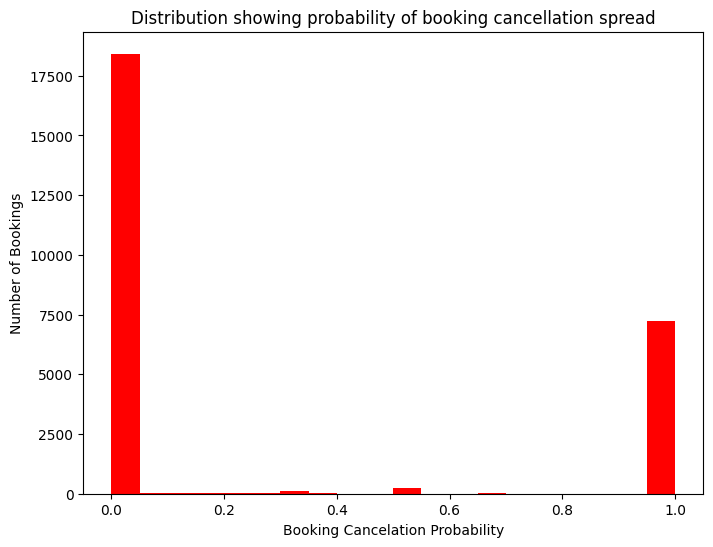

In [86]:
print("Summary Statistics")
print(prediction_dt[['dt_pred_0', 'dt_pred_1']].describe())
plt.figure(figsize= (8,6))
plt.hist(data= prediction_dt, x = 'dt_pred_1', color = 'red', bins=20)
plt.title('Distribution showing probability of booking cancellation spread')
plt.xlabel('Booking Cancelation Probability')
plt.ylabel('Number of Bookings')
plt.show()

So we can notice that the decision tree is performing better so far in predicting cancellation coreectly. 

## Random Forest and Gradient Boosting

## Random Forest and XG Boosting

In [87]:
import joblib

N_CORES = joblib.cpu_count(only_physical_cores=True) -1
print(f"Number of physical CPU cores: {N_CORES}")

Number of physical CPU cores: 13


In [88]:
import warnings
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support
warnings.filterwarnings("ignore")

# Model Specification
models = {
    'Random Forest': RandomForestClassifier(random_state=19),
    'XGBoost': XGBClassifier(random_state=19, eval_metric='logloss')
}

# Hyperparameter Tunning
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 250, 350],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'n_estimators': [100, 150, 250, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

# Use CV for model training
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=19)

# Apply GridSearchCV for best model selection and return the model with best parameter
results = []
for model_name, model in models.items():
    print(f"Training {model_name}...")
    grid_search = GridSearchCV(
        model,
        param_grids[model_name],
        cv=cv,
        scoring='roc_auc',
        n_jobs=N_CORES,
        refit=True,
        error_score='raise'
    )
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary'
    )
    
    results.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Best CV ROC AUC': grid_search.best_score_,
        'Test ROC AUC': roc_auc,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })

Training Random Forest...
Training XGBoost...


In [89]:
print("Model Tuning Results:")
results_df = pd.DataFrame(results)
print(results_df)

Model Tuning Results:
           Model                                    Best Parameters  \
0  Random Forest  {'max_depth': 20, 'min_samples_leaf': 2, 'min_...   
1        XGBoost  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...   

   Best CV ROC AUC  Test ROC AUC  Accuracy  Precision    Recall        F1  
0         0.768870      0.778719  0.758877   0.675794  0.236265  0.350123  
1         0.763233      0.773586  0.757237   0.645596  0.259295  0.369989  


Best model after optimization is `XGClassifier` of 150 n_estimators and 0.1 `learning_rate`.

In [90]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

Not Canceled       0.77      0.95      0.85     19011
    Canceled       0.65      0.26      0.37      7208

    accuracy                           0.76     26219
   macro avg       0.71      0.60      0.61     26219
weighted avg       0.74      0.76      0.72     26219



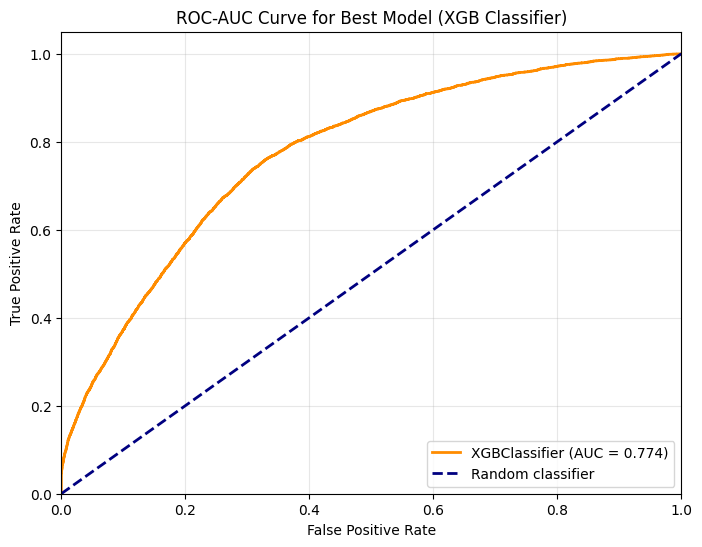

In [94]:
# ROC-AUC curve for the selected best model
best_model_name = type(best_model).__name__
best_model_proba = best_model.predict_proba(X_test)[:, 1]

fpr_best, tpr_best, _ = roc_curve(y_test, best_model_proba)
roc_auc_best = roc_auc_score(y_test, best_model_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_best, tpr_best, color="darkorange", lw=2,
    label=f"{best_model_name} (AUC = {roc_auc_best:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random classifier")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve for Best Model (XGB Classifier)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Combine test features, actual labels, predictions, and XGBoost probabilities
xgb_proba = pd.DataFrame(
    best_model.predict_proba(X_test),
    columns=["xgb_pred_0", "xgb_pred_1"],
    index=X_test.index
)

prediction_xgb = X_test.copy()
prediction_xgb["actual"] = y_test
prediction_xgb["predicted"] = best_model.predict(X_test)
prediction_xgb = prediction_xgb.join(xgb_proba)

prediction_xgb.head()

In [47]:
import warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

# --- Class imbalance info ---
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos
print(f"Positive: {n_pos}, Negative: {n_neg}, scale_pos_weight: {scale_pos_weight:.2f}")

# --- Models with imbalance handling ---
models = {
    'Random Forest': RandomForestClassifier(random_state=19, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=19, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 250, 350],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'n_estimators': [100, 150, 250, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=19)

results = []
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=cv,
                               scoring='roc_auc', n_jobs=N_CORES,
                               refit=True, error_score='raise')
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    # Default 0.5 threshold predictions
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary')

    results.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Best CV ROC AUC': grid_search.best_score_,
        'Test ROC AUC': roc_auc,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
    })

results_df = pd.DataFrame(results)
print("\n=== Model Tuning Results ===")
print(results_df.to_string(index=False))

Positive: 16817, Negative: 44360, scale_pos_weight: 2.64

Training Random Forest...

Training XGBoost...

=== Model Tuning Results ===
        Model                                                                       Best Parameters  Best CV ROC AUC  Test ROC AUC  Accuracy  Precision   Recall       F1
Random Forest {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 350}         0.766587      0.776416  0.704985   0.476082 0.727664 0.575583
      XGBoost         {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150, 'subsample': 1.0}         0.763288      0.772898  0.695869   0.466851 0.748335 0.574992


In [48]:
grid_search.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, random_state=19, ...)

In [49]:
# classification report for best model
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

Not Canceled       0.88      0.68      0.76     19011
    Canceled       0.47      0.75      0.57      7208

    accuracy                           0.70     26219
   macro avg       0.67      0.71      0.67     26219
weighted avg       0.76      0.70      0.71     26219



In [51]:
pd.DataFrame(y_pred_proba)

,0
0,0.221358
1,0.329271
2,0.226842
3,0.135853
4,0.385448
...,...
26214,0.619506
26215,0.238706
26216,0.618308
26217,0.447856


In [ ]:
# Feature Importance

In [ ]:
# ROC AUC

# Part II

In [61]:
# drop market segment == 'complementary' from the dataset
hotel_bookings_copy2 = hotel_bookings[hotel_bookings['market_segment'] != 'Complementary']
# Drop bookings greater than 1000 in data-- turns out only 1 booking has adr > 1000 (actual 5400), so we can drop it to avoid skewing the data
hotel_bookings_copy2 = hotel_bookings_copy2[hotel_bookings_copy2['adr'] < 1000] 
# drop adr < 0
hotel_bookings_copy2 = hotel_bookings_copy2[hotel_bookings_copy2['adr'] >= 0]

In [70]:
hotel_bookings_copy2['family_flag'] = hotel_bookings['family_flag'].astype('category') 

New_Features_Cols = ['total_of_special_requests', 'adults', 'family_flag',
    'lead_time', 'market_segment', 'distribution_channel', 'customer_type',
    'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'hotel',
    'deposit_type', 'arrival_date_month', 'arrival_date_week_number'
]

new_num_cols = ['total_of_special_requests', 'adults', 'lead_time', 'stays_in_week_nights', 'stays_in_weekend_nights', 'adr', 'arrival_date_week_number']
new_cat_cols = [c for c in New_Features_Cols if c not in new_num_cols]

#X_new = hotel_bookings_copy2[New_Features_Cols]
X_new = pd.get_dummies(hotel_bookings_copy2[New_Features_Cols], drop_first=False)
y_new = hotel_bookings_copy2['is_canceled']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.3, stratify=y, random_state=19)

In [72]:
import warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_recall_fscore_support
)

warnings.filterwarnings("ignore")

# --- Class imbalance info ---
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
scale_pos_weight = n_neg / n_pos
print(f"Positive: {n_pos}, Negative: {n_neg}, scale_pos_weight: {scale_pos_weight:.2f}")

# --- Models with imbalance handling ---
models = {
    'Random Forest': RandomForestClassifier(random_state=19, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=19, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

param_grids = {
    'Random Forest': {
        'n_estimators': [100, 150, 250, 350],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'XGBoost': {
        'n_estimators': [100, 150, 250, 400],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=19)

results = []
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    grid_search = GridSearchCV(model, param_grids[model_name], cv=cv,
                               scoring='roc_auc', n_jobs=N_CORES,
                               refit=True, error_score='raise')
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    # Default 0.5 threshold predictions
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='binary')

    results.append({
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Best CV ROC AUC': grid_search.best_score_,
        'Test ROC AUC': roc_auc,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
    })

results_df_3 = pd.DataFrame(results)
print("\n=== Model Tuning Results ===")
print(results_df_3.to_string(index=False))

Positive: 16755, Negative: 43929, scale_pos_weight: 2.62

Training Random Forest...

Training XGBoost...

=== Model Tuning Results ===
        Model                                                                         Best Parameters  Best CV ROC AUC  Test ROC AUC  Accuracy  Precision   Recall       F1
Random Forest {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 350}         0.810348      0.810338  0.781529   0.605936 0.596992 0.601431
      XGBoost           {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 250, 'subsample': 0.8}         0.806695      0.807703  0.753114   0.541295 0.693636 0.608069


In [73]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

Not Canceled       0.87      0.78      0.82     18827
    Canceled       0.54      0.69      0.61      7181

    accuracy                           0.75     26008
   macro avg       0.71      0.73      0.71     26008
weighted avg       0.78      0.75      0.76     26008

